# 📦 AWS Supply Chain Orders — Full Analysis Notebook
**Dataset:** `aws_supply_chain_orders_raw.csv`  
**Columns:** order_id · warehouse · region · product · order_qty · order_date · delivery_date · delivery_time_days · status  
**Rows:** 155 orders across 3 warehouses (WH-A, WH-B, WH-C) and 5 products

---
> Run cells top to bottom. Each section is self-contained with comments explaining every line.


## 1. 📥 Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)        # show all columns
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimal places
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("✅ Imports done")

✅ Imports done


## 2. 📂 Load & Inspect the Dataset

In [2]:
df = pd.read_csv("aws_supply_chain_orders_raw.csv")

print("Shape:", df.shape)           # (rows, columns)
print("Columns:", df.columns.tolist())
df.head(5)                          # first 5 rows

Shape: (155, 9)
Columns: ['order_id', 'warehouse', 'region', 'product', 'order_qty', 'order_date', 'delivery_date', 'delivery_time_days', 'status']


,order_id,warehouse,region,product,order_qty,order_date,delivery_date,delivery_time_days,status
0,ORD-1000,WH-C,West,Router,42,2026-02-16 06:22:56.185879,2026-03-24 06:22:56.186200,4.00,Pending
1,ORD-1001,WH-A,West,Laptop,30,2026-02-25 06:22:56.185905,2026-03-15 06:22:56.186205,12.00,Pending
2,ORD-1002,WH-C,South,Switch,19,2026-03-13 06:22:56.185910,2026-03-13 06:22:56.186207,13.00,Pending
3,ORD-1003,WH-C,North,Server,17,2026-02-14 06:22:56.185913,2026-03-01 06:22:56.186209,9.00,Pending
4,ORD-1004,WH-A,East,Laptop,19,2026-02-18 06:22:56.185916,2026-03-11 06:22:56.186211,3.00,Delivered


In [3]:
df.info()                             # dtypes + non-null counts + memory

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            155 non-null    object 
 1   warehouse           155 non-null    object 
 2   region              150 non-null    object 
 3   product             155 non-null    object 
 4   order_qty           155 non-null    int64  
 5   order_date          155 non-null    object 
 6   delivery_date       155 non-null    object 
 7   delivery_time_days  144 non-null    float64
 8   status              155 non-null    object 
dtypes: float64(1), int64(1), object(7)
memory usage: 11.0+ KB


In [4]:
df.describe()                         # stats for numeric columns only

,order_qty,delivery_time_days
count,155.00,144.00
mean,26.03,8.04
std,13.61,4.00
min,1.00,1.00
25%,16.00,5.00
50%,26.00,8.50
75%,36.00,12.00
max,49.00,14.00


In [5]:
# Describe ALL columns including strings
df.describe(include='all')

,order_id,warehouse,region,product,order_qty,order_date,delivery_date,delivery_time_days,status
count,155,155,150,155,155.00,155,155,144.00,155
unique,150,3,4,5,NaN,150,150,NaN,3
top,ORD-1082,WH-C,West,Laptop,NaN,2026-01-29 06:22:56.186062,2026-03-05 06:22:56.186350,NaN,Delivered
freq,2,58,43,37,NaN,2,2,NaN,61
mean,NaN,NaN,NaN,NaN,26.03,NaN,NaN,8.04,NaN
std,NaN,NaN,NaN,NaN,13.61,NaN,NaN,4.00,NaN
min,NaN,NaN,NaN,NaN,1.00,NaN,NaN,1.00,NaN
25%,NaN,NaN,NaN,NaN,16.00,NaN,NaN,5.00,NaN
50%,NaN,NaN,NaN,NaN,26.00,NaN,NaN,8.50,NaN
75%,NaN,NaN,NaN,NaN,36.00,NaN,NaN,12.00,NaN


In [6]:
# Unique value counts per categorical column
for col in ['warehouse', 'region', 'product', 'status']:
    print(f"{col}: {df[col].unique()}")

warehouse: ['WH-C' 'WH-A' 'WH-B']
region: ['West' 'South' 'North' 'East' nan]
product: ['Router' 'Laptop' 'Switch' 'Server' 'Storage']
status: ['Pending' 'Delivered' 'Delayed']


In [7]:
df.sample(5, random_state=42)         # random 5 rows

,order_id,warehouse,region,product,order_qty,order_date,delivery_date,delivery_time_days,status
81,ORD-1081,WH-A,North,Storage,37,2026-02-24 06:22:56.186060,2026-03-09 06:22:56.186349,11.00,Pending
142,ORD-1142,WH-B,West,Server,49,2026-02-14 06:22:56.186165,2026-03-08 06:22:56.186452,12.00,Pending
31,ORD-1031,WH-C,South,Server,37,2026-03-05 06:22:56.185974,2026-03-05 06:22:56.186259,14.00,Delivered
29,ORD-1029,WH-C,West,Switch,26,2026-03-12 06:22:56.185970,2026-03-08 06:22:56.186255,10.00,Delayed
118,ORD-1118,WH-C,South,Storage,9,2026-03-19 06:22:56.186124,2026-03-07 06:22:56.186410,13.00,Pending


## 3. 🧹 Null Value Detection & Handling

In [ ]:
# Count nulls per column in the columns 
df.isnull().sum()

order_id               0
warehouse              0
region                 5
product                0
order_qty              0
order_date             0
delivery_date          0
delivery_time_days    11
status                 0
dtype: int64

TypeError: plot() got an unexpected keyword argument 'y'

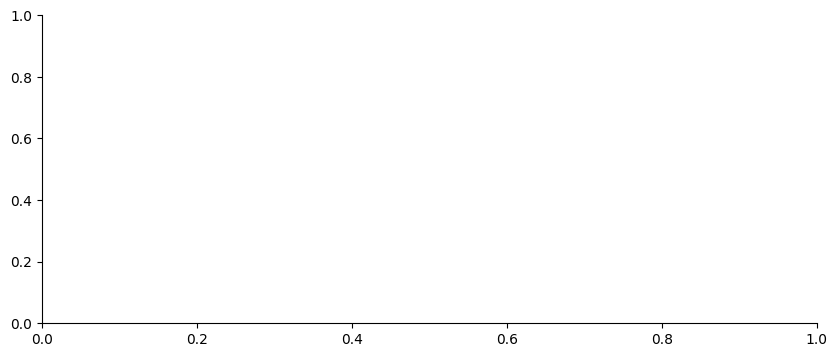

In [73]:
x = [1,2,3,4]
y = [90,100,45,83]
z = [40,50,90,34]

plt.plot(x,y = "dsa marks",z = "maths marks")
plt.title("Lines in the lines are linin ")
plt.xlabel("plots on x are xing")
plt.ylabel("plots on y are ying")
plt.show()

In [9]:
# Null percentage per column
(df.isnull().sum() / len(df) * 100).round(2).rename("null %")

order_id             0.00
warehouse            0.00
region               3.23
product              0.00
order_qty            0.00
order_date           0.00
delivery_date        0.00
delivery_time_days   7.10
status               0.00
Name: null %, dtype: float64

In [10]:
# See the actual rows with nulls in delivery_time_days
df[df['delivery_time_days'].isnull()]

,order_id,warehouse,region,product,order_qty,order_date,delivery_date,delivery_time_days,status
18,ORD-1018,WH-B,South,Storage,25,2026-01-28 06:22:56.185942,2026-02-25 06:22:56.186237,NaN,Delivered
22,ORD-1022,WH-B,North,Laptop,16,2026-03-17 06:22:56.185949,2026-03-04 06:22:56.186243,NaN,Delivered
56,ORD-1056,WH-C,North,Storage,36,2026-03-18 06:22:56.186017,2026-03-16 06:22:56.186308,NaN,Delayed
58,ORD-1058,WH-C,East,Switch,31,2026-03-13 06:22:56.186021,2026-03-23 06:22:56.186311,NaN,Delivered
82,ORD-1082,WH-B,North,Laptop,12,2026-01-29 06:22:56.186062,2026-03-05 06:22:56.186350,NaN,Delivered
109,ORD-1109,WH-B,West,Router,45,2026-01-23 06:22:56.186108,2026-03-16 06:22:56.186395,NaN,Pending
124,ORD-1124,WH-C,North,Router,36,2026-02-09 06:22:56.186134,2026-02-24 06:22:56.186420,NaN,Delayed
126,ORD-1126,WH-C,West,Switch,49,2026-03-17 06:22:56.186137,2026-03-12 06:22:56.186424,NaN,Delivered
129,ORD-1129,WH-B,West,Storage,24,2026-03-02 06:22:56.186143,2026-03-21 06:22:56.186429,NaN,Delayed
136,ORD-1136,WH-B,East,Server,23,2026-02-17 06:22:56.186155,2026-03-18 06:22:56.186442,NaN,Delivered


In [11]:
# Option A: Fill delivery_time_days nulls with median
df['delivery_time_days'] = df['delivery_time_days'].fillna(df['delivery_time_days'].median())

# Option B: Fill region nulls with 'Unknown'
df['region'] = df['region'].fillna('Unknown')

print("Nulls remaining:", df.isnull().sum().sum())
df.tail()

Nulls remaining: 0


,order_id,warehouse,region,product,order_qty,order_date,delivery_date,delivery_time_days,status
150,ORD-1101,WH-C,South,Router,29,2026-02-02 06:22:56.186094,2026-03-06 06:22:56.186381,3.00,Delivered
151,ORD-1082,WH-B,North,Laptop,12,2026-01-29 06:22:56.186062,2026-03-05 06:22:56.186350,8.50,Delivered
152,ORD-1031,WH-C,South,Server,37,2026-03-05 06:22:56.185974,2026-03-05 06:22:56.186259,14.00,Delivered
153,ORD-1064,WH-B,South,Laptop,45,2026-02-06 06:22:56.186031,2026-03-05 06:22:56.186321,13.00,Delivered
154,ORD-1067,WH-B,West,Storage,24,2026-03-17 06:22:56.186036,2026-02-26 06:22:56.186326,4.00,Delivered


## 4. 🔧 Fix Data Types

In [12]:
# Convert date strings → datetime objects
df['order_date']    = pd.to_datetime(df['order_date'])
df['delivery_date'] = pd.to_datetime(df['delivery_date'])

# Convert status to categorical (saves memory, enables cat operations)
df['status'] = df['status'].astype('category')

print(df.dtypes)

order_id                      object
warehouse                     object
region                        object
product                       object
order_qty                      int64
order_date            datetime64[ns]
delivery_date         datetime64[ns]
delivery_time_days           float64
status                      category
dtype: object


In [13]:
# Extract date parts into new columns
df['order_year']    = df['order_date'].dt.year
df['order_month']   = df['order_date'].dt.month
df['order_weekday'] = df['order_date'].dt.day_name()

df[['order_date', 'order_year', 'order_month', 'order_weekday']].head()

,order_date,order_year,order_month,order_weekday
0,2026-02-16 06:22:56.185879,2026,2,Monday
1,2026-02-25 06:22:56.185905,2026,2,Wednesday
2,2026-03-13 06:22:56.185910,2026,3,Friday
3,2026-02-14 06:22:56.185913,2026,2,Saturday
4,2026-02-18 06:22:56.185916,2026,2,Wednesday


## 5. ➕ Creating Derived / Computed Columns

In [14]:
# Actual delivery days (from raw timestamps)
df['actual_days'] = (df['delivery_date'] - df['order_date']).dt.days

# Delivery gap: positive = late, negative = early
df['delivery_gap'] = df['actual_days'] - df['delivery_time_days']

# Boolean: was the order delayed vs on-time?
df['is_delayed'] = df['status'] == 'Delayed'
df['is_delivered'] = df['status'] == 'Delivered'

# Quantity tier using pd.cut (bin into low/medium/high)
df['qty_tier'] = pd.cut(df['order_qty'],
    bins=[0, 15, 30, 50],
    labels=['low', 'medium', 'high'])

df[['order_id', 'order_qty', 'qty_tier', 'actual_days', 'delivery_gap', 'is_delayed']].head(8)

,order_id,order_qty,qty_tier,actual_days,delivery_gap,is_delayed
0,ORD-1000,42,high,36,32.00,False
1,ORD-1001,30,medium,18,6.00,False
2,ORD-1002,19,medium,0,-13.00,False
3,ORD-1003,17,medium,15,6.00,False
4,ORD-1004,19,medium,21,18.00,False
5,ORD-1005,28,medium,-16,-28.00,False
6,ORD-1006,26,medium,-14,-23.00,True
7,ORD-1007,37,high,17,10.00,False


In [15]:
# np.where — conditional column (like Excel IF)
df['urgency'] = np.where(df['delivery_time_days'] <= 5, 'urgent', 'standard')

# np.select — multi-condition labeling
conditions = [
    df['delivery_time_days'] <= 5,
    df['delivery_time_days'] <= 10,
    df['delivery_time_days'] > 10
]
choices = ['fast', 'normal', 'slow']
df['speed_label'] = np.select(conditions, choices, default='unknown')


df[['order_id', 'delivery_time_days', 'urgency', 'speed_label']].head(8)

,order_id,delivery_time_days,urgency,speed_label
0,ORD-1000,4.00,urgent,fast
1,ORD-1001,12.00,standard,slow
2,ORD-1002,13.00,standard,slow
3,ORD-1003,9.00,standard,normal
4,ORD-1004,3.00,urgent,fast
5,ORD-1005,12.00,standard,slow
6,ORD-1006,9.00,standard,normal
7,ORD-1007,7.00,standard,normal


## 6. 🔍 Filtering, Selecting & Slicing

In [16]:
# Single condition
df[df['status'] == 'Delayed']

,order_id,warehouse,region,product,order_qty,order_date,delivery_date,delivery_time_days,status,order_year,order_month,order_weekday,actual_days,delivery_gap,is_delayed,is_delivered,qty_tier,urgency,speed_label
6,ORD-1006,WH-C,North,Router,26,2026-03-15 06:22:56.185920,2026-03-01 06:22:56.186215,9.00,Delayed,2026,3,Sunday,-14,-23.00,True,False,medium,standard,normal
8,ORD-1008,WH-C,East,Switch,26,2026-02-15 06:22:56.185924,2026-03-13 06:22:56.186218,12.00,Delayed,2026,2,Sunday,26,14.00,True,False,medium,standard,slow
17,ORD-1017,WH-B,West,Server,48,2026-03-14 06:22:56.185940,2026-03-03 06:22:56.186235,9.00,Delayed,2026,3,Saturday,-11,-20.00,True,False,high,standard,normal
21,ORD-1021,WH-A,South,Laptop,1,2026-02-18 06:22:56.185947,2026-03-16 06:22:56.186242,4.00,Delayed,2026,2,Wednesday,26,22.00,True,False,low,urgent,fast
23,ORD-1023,WH-B,North,Switch,39,2026-03-10 06:22:56.185951,2026-03-14 06:22:56.186245,7.00,Delayed,2026,3,Tuesday,4,-3.00,True,False,high,standard,normal
29,ORD-1029,WH-C,West,Switch,26,2026-03-12 06:22:56.185970,2026-03-08 06:22:56.186255,10.00,Delayed,2026,3,Thursday,-4,-14.00,True,False,medium,standard,normal
32,ORD-1032,WH-B,East,Server,22,2026-03-19 06:22:56.185976,2026-03-04 06:22:56.186260,10.00,Delayed,2026,3,Thursday,-15,-25.00,True,False,medium,standard,normal
37,ORD-1037,WH-C,North,Storage,47,2026-03-04 06:22:56.185984,2026-03-24 06:22:56.186269,11.00,Delayed,2026,3,Wednesday,20,9.00,True,False,high,standard,slow
39,ORD-1039,WH-C,South,Router,30,2026-03-01 06:22:56.185988,2026-03-20 06:22:56.186272,2.00,Delayed,2026,3,Sunday,19,17.00,True,False,medium,urgent,fast
42,ORD-1042,WH-C,North,Storage,12,2026-03-07 06:22:56.185993,2026-03-16 06:22:56.186285,10.00,Delayed,2026,3,Saturday,9,-1.00,True,False,low,standard,normal


In [17]:
# Multiple conditions with & (AND) and | (OR)
df[(df['status'] == 'Delayed') & (df['region'] == 'North')]

,order_id,warehouse,region,product,order_qty,order_date,delivery_date,delivery_time_days,status,order_year,order_month,order_weekday,actual_days,delivery_gap,is_delayed,is_delivered,qty_tier,urgency,speed_label
6,ORD-1006,WH-C,North,Router,26,2026-03-15 06:22:56.185920,2026-03-01 06:22:56.186215,9.00,Delayed,2026,3,Sunday,-14,-23.00,True,False,medium,standard,normal
23,ORD-1023,WH-B,North,Switch,39,2026-03-10 06:22:56.185951,2026-03-14 06:22:56.186245,7.00,Delayed,2026,3,Tuesday,4,-3.00,True,False,high,standard,normal
37,ORD-1037,WH-C,North,Storage,47,2026-03-04 06:22:56.185984,2026-03-24 06:22:56.186269,11.00,Delayed,2026,3,Wednesday,20,9.00,True,False,high,standard,slow
42,ORD-1042,WH-C,North,Storage,12,2026-03-07 06:22:56.185993,2026-03-16 06:22:56.186285,10.00,Delayed,2026,3,Saturday,9,-1.00,True,False,low,standard,normal
45,ORD-1045,WH-C,North,Laptop,26,2026-02-22 06:22:56.185998,2026-03-09 06:22:56.186290,1.00,Delayed,2026,2,Sunday,15,14.00,True,False,medium,urgent,fast
56,ORD-1056,WH-C,North,Storage,36,2026-03-18 06:22:56.186017,2026-03-16 06:22:56.186308,8.50,Delayed,2026,3,Wednesday,-2,-10.50,True,False,high,standard,normal
86,ORD-1086,WH-C,North,Laptop,40,2026-02-27 06:22:56.186069,2026-03-03 06:22:56.186357,14.00,Delayed,2026,2,Friday,4,-10.00,True,False,high,standard,slow
92,ORD-1092,WH-A,North,Router,12,2026-03-17 06:22:56.186079,2026-03-05 06:22:56.186367,14.00,Delayed,2026,3,Tuesday,-12,-26.00,True,False,low,standard,slow
111,ORD-1111,WH-B,North,Router,29,2026-02-27 06:22:56.186112,2026-02-27 06:22:56.186398,6.00,Delayed,2026,2,Friday,0,-6.00,True,False,medium,standard,normal
124,ORD-1124,WH-C,North,Router,36,2026-02-09 06:22:56.186134,2026-02-24 06:22:56.186420,8.50,Delayed,2026,2,Monday,15,6.50,True,False,high,standard,normal


In [18]:
# .isin() — match multiple values at once
df[df['product'].isin(['Laptop', 'Server'])]

,order_id,warehouse,region,product,order_qty,order_date,delivery_date,delivery_time_days,status,order_year,order_month,order_weekday,actual_days,delivery_gap,is_delayed,is_delivered,qty_tier,urgency,speed_label
1,ORD-1001,WH-A,West,Laptop,30,2026-02-25 06:22:56.185905,2026-03-15 06:22:56.186205,12.00,Pending,2026,2,Wednesday,18,6.00,False,False,medium,standard,slow
3,ORD-1003,WH-C,North,Server,17,2026-02-14 06:22:56.185913,2026-03-01 06:22:56.186209,9.00,Pending,2026,2,Saturday,15,6.00,False,False,medium,standard,normal
4,ORD-1004,WH-A,East,Laptop,19,2026-02-18 06:22:56.185916,2026-03-11 06:22:56.186211,3.00,Delivered,2026,2,Wednesday,21,18.00,False,True,medium,urgent,fast
5,ORD-1005,WH-A,East,Laptop,28,2026-03-12 06:22:56.185918,2026-02-24 06:22:56.186213,12.00,Delivered,2026,3,Thursday,-16,-28.00,False,True,medium,standard,slow
9,ORD-1009,WH-C,North,Server,23,2026-03-12 06:22:56.185926,2026-03-06 06:22:56.186220,14.00,Delivered,2026,3,Thursday,-6,-20.00,False,True,medium,standard,slow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,ORD-1146,WH-C,North,Server,22,2026-01-31 06:22:56.186172,2026-02-23 06:22:56.186458,12.00,Delivered,2026,1,Saturday,23,11.00,False,True,medium,standard,slow
148,ORD-1148,WH-A,West,Server,19,2026-02-18 06:22:56.186176,2026-03-07 06:22:56.186462,12.00,Delayed,2026,2,Wednesday,17,5.00,True,False,medium,standard,slow
151,ORD-1082,WH-B,North,Laptop,12,2026-01-29 06:22:56.186062,2026-03-05 06:22:56.186350,8.50,Delivered,2026,1,Thursday,35,26.50,False,True,low,standard,normal
152,ORD-1031,WH-C,South,Server,37,2026-03-05 06:22:56.185974,2026-03-05 06:22:56.186259,14.00,Delivered,2026,3,Thursday,0,-14.00,False,True,high,standard,slow


In [19]:
# ~ means NOT
df[~df['status'].isin(['Delivered'])]

,order_id,warehouse,region,product,order_qty,order_date,delivery_date,delivery_time_days,status,order_year,order_month,order_weekday,actual_days,delivery_gap,is_delayed,is_delivered,qty_tier,urgency,speed_label
0,ORD-1000,WH-C,West,Router,42,2026-02-16 06:22:56.185879,2026-03-24 06:22:56.186200,4.00,Pending,2026,2,Monday,36,32.00,False,False,high,urgent,fast
1,ORD-1001,WH-A,West,Laptop,30,2026-02-25 06:22:56.185905,2026-03-15 06:22:56.186205,12.00,Pending,2026,2,Wednesday,18,6.00,False,False,medium,standard,slow
2,ORD-1002,WH-C,South,Switch,19,2026-03-13 06:22:56.185910,2026-03-13 06:22:56.186207,13.00,Pending,2026,3,Friday,0,-13.00,False,False,medium,standard,slow
3,ORD-1003,WH-C,North,Server,17,2026-02-14 06:22:56.185913,2026-03-01 06:22:56.186209,9.00,Pending,2026,2,Saturday,15,6.00,False,False,medium,standard,normal
6,ORD-1006,WH-C,North,Router,26,2026-03-15 06:22:56.185920,2026-03-01 06:22:56.186215,9.00,Delayed,2026,3,Sunday,-14,-23.00,True,False,medium,standard,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,ORD-1143,WH-B,East,Storage,20,2026-02-19 06:22:56.186167,2026-02-25 06:22:56.186453,10.00,Pending,2026,2,Thursday,6,-4.00,False,False,medium,standard,normal
145,ORD-1145,WH-C,North,Storage,25,2026-02-25 06:22:56.186170,2026-03-10 06:22:56.186457,6.00,Pending,2026,2,Wednesday,13,7.00,False,False,medium,standard,normal
147,ORD-1147,WH-C,Unknown,Switch,13,2026-02-20 06:22:56.186174,2026-03-08 06:22:56.186460,8.00,Pending,2026,2,Friday,16,8.00,False,False,low,standard,normal
148,ORD-1148,WH-A,West,Server,19,2026-02-18 06:22:56.186176,2026-03-07 06:22:56.186462,12.00,Delayed,2026,2,Wednesday,17,5.00,True,False,medium,standard,slow


In [20]:
# .loc — label-based: select rows AND specific columns
df.loc[df['warehouse'] == 'WH-A', ['order_id', 'product', 'order_qty', 'status']]

,order_id,product,order_qty,status
1,ORD-1001,Laptop,30,Pending
4,ORD-1004,Laptop,19,Delivered
5,ORD-1005,Laptop,28,Delivered
12,ORD-1012,Server,1,Delivered
15,ORD-1015,Router,34,Delivered
20,ORD-1020,Switch,45,Pending
21,ORD-1021,Laptop,1,Delayed
24,ORD-1024,Switch,5,Delivered
25,ORD-1025,Switch,22,Pending
26,ORD-1026,Server,29,Pending


In [21]:
# .iloc — position-based: rows 10–20, first 4 columns
df.iloc[10:20, 0:4]

,order_id,warehouse,region,product
10,ORD-1010,WH-C,West,Router
11,ORD-1011,WH-C,North,Laptop
12,ORD-1012,WH-A,West,Server
13,ORD-1013,WH-C,East,Server
14,ORD-1014,WH-B,East,Laptop
15,ORD-1015,WH-A,East,Router
16,ORD-1016,WH-B,South,Laptop
17,ORD-1017,WH-B,West,Server
18,ORD-1018,WH-B,South,Storage
19,ORD-1019,WH-B,South,Storage


In [22]:
# .query() — readable SQL-style filtering
df.query("order_qty > 40 and status == 'Pending'")

,order_id,warehouse,region,product,order_qty,order_date,delivery_date,delivery_time_days,status,order_year,order_month,order_weekday,actual_days,delivery_gap,is_delayed,is_delivered,qty_tier,urgency,speed_label
0,ORD-1000,WH-C,West,Router,42,2026-02-16 06:22:56.185879,2026-03-24 06:22:56.186200,4.00,Pending,2026,2,Monday,36,32.00,False,False,high,urgent,fast
20,ORD-1020,WH-A,North,Switch,45,2026-03-01 06:22:56.185946,2026-02-22 06:22:56.186240,5.00,Pending,2026,3,Sunday,-7,-12.00,False,False,high,urgent,fast
70,ORD-1070,WH-C,North,Switch,49,2026-02-01 06:22:56.186041,2026-03-19 06:22:56.186331,9.00,Pending,2026,2,Sunday,46,37.00,False,False,high,standard,normal
88,ORD-1088,WH-B,South,Storage,43,2026-03-16 06:22:56.186072,2026-02-27 06:22:56.186360,13.00,Pending,2026,3,Monday,-17,-30.00,False,False,high,standard,slow
89,ORD-1089,WH-A,West,Storage,44,2026-03-18 06:22:56.186074,2026-03-24 06:22:56.186362,13.00,Pending,2026,3,Wednesday,6,-7.00,False,False,high,standard,slow
94,ORD-1094,WH-A,North,Router,46,2026-02-18 06:22:56.186082,2026-03-20 06:22:56.186370,4.00,Pending,2026,2,Wednesday,30,26.00,False,False,high,urgent,fast
109,ORD-1109,WH-B,West,Router,45,2026-01-23 06:22:56.186108,2026-03-16 06:22:56.186395,8.50,Pending,2026,1,Friday,52,43.50,False,False,high,standard,normal
139,ORD-1139,WH-A,East,Storage,41,2026-03-01 06:22:56.186160,2026-02-24 06:22:56.186447,7.00,Pending,2026,3,Sunday,-5,-12.00,False,False,high,standard,normal
142,ORD-1142,WH-B,West,Server,49,2026-02-14 06:22:56.186165,2026-03-08 06:22:56.186452,12.00,Pending,2026,2,Saturday,22,10.00,False,False,high,standard,slow


## 7. 🔃 Sorting & Ranking

In [23]:
# Sort by single column
df.sort_values('order_qty', ascending=False).head(10)

,order_id,warehouse,region,product,order_qty,order_date,delivery_date,delivery_time_days,status,order_year,order_month,order_weekday,actual_days,delivery_gap,is_delayed,is_delivered,qty_tier,urgency,speed_label
149,ORD-1149,WH-A,East,Storage,49,2026-02-15 06:22:56.186196,2026-02-26 06:22:56.186464,5.00,Delayed,2026,2,Sunday,11,6.00,True,False,high,urgent,fast
70,ORD-1070,WH-C,North,Switch,49,2026-02-01 06:22:56.186041,2026-03-19 06:22:56.186331,9.00,Pending,2026,2,Sunday,46,37.00,False,False,high,standard,normal
38,ORD-1038,WH-A,East,Router,49,2026-01-24 06:22:56.185986,2026-02-25 06:22:56.186270,11.00,Delivered,2026,1,Saturday,32,21.00,False,True,high,standard,slow
142,ORD-1142,WH-B,West,Server,49,2026-02-14 06:22:56.186165,2026-03-08 06:22:56.186452,12.00,Pending,2026,2,Saturday,22,10.00,False,False,high,standard,slow
121,ORD-1121,WH-C,East,Server,49,2026-02-15 06:22:56.186129,2026-03-22 06:22:56.186416,5.00,Delayed,2026,2,Sunday,35,30.00,True,False,high,urgent,fast
134,ORD-1134,WH-C,East,Router,49,2026-03-19 06:22:56.186151,2026-03-06 06:22:56.186438,1.00,Delivered,2026,3,Thursday,-13,-14.00,False,True,high,urgent,fast
126,ORD-1126,WH-C,West,Switch,49,2026-03-17 06:22:56.186137,2026-03-12 06:22:56.186424,8.50,Delivered,2026,3,Tuesday,-5,-13.50,False,True,high,standard,normal
46,ORD-1046,WH-B,West,Server,48,2026-03-04 06:22:56.186000,2026-02-27 06:22:56.186291,13.00,Delayed,2026,3,Wednesday,-5,-18.00,True,False,high,standard,slow
17,ORD-1017,WH-B,West,Server,48,2026-03-14 06:22:56.185940,2026-03-03 06:22:56.186235,9.00,Delayed,2026,3,Saturday,-11,-20.00,True,False,high,standard,normal
144,ORD-1144,WH-A,West,Server,48,2026-03-16 06:22:56.186169,2026-02-24 06:22:56.186455,8.00,Delivered,2026,3,Monday,-20,-28.00,False,True,high,standard,normal


In [24]:
# Multi-column sort: region A-Z, then delivery time descending
df.sort_values(['region', 'delivery_time_days'], ascending=[True, False]).head(10)

,order_id,warehouse,region,product,order_qty,order_date,delivery_date,delivery_time_days,status,order_year,order_month,order_weekday,actual_days,delivery_gap,is_delayed,is_delivered,qty_tier,urgency,speed_label
50,ORD-1050,WH-B,East,Switch,33,2026-01-29 06:22:56.186007,2026-02-28 06:22:56.186298,13.00,Pending,2026,1,Thursday,30,17.00,False,False,high,standard,slow
77,ORD-1077,WH-C,East,Switch,35,2026-02-03 06:22:56.186053,2026-03-07 06:22:56.186343,13.00,Delivered,2026,2,Tuesday,32,19.00,False,True,high,standard,slow
5,ORD-1005,WH-A,East,Laptop,28,2026-03-12 06:22:56.185918,2026-02-24 06:22:56.186213,12.00,Delivered,2026,3,Thursday,-16,-28.00,False,True,medium,standard,slow
8,ORD-1008,WH-C,East,Switch,26,2026-02-15 06:22:56.185924,2026-03-13 06:22:56.186218,12.00,Delayed,2026,2,Sunday,26,14.00,True,False,medium,standard,slow
91,ORD-1091,WH-A,East,Switch,13,2026-03-19 06:22:56.186077,2026-03-21 06:22:56.186365,12.00,Pending,2026,3,Thursday,2,-10.00,False,False,low,standard,slow
38,ORD-1038,WH-A,East,Router,49,2026-01-24 06:22:56.185986,2026-02-25 06:22:56.186270,11.00,Delivered,2026,1,Saturday,32,21.00,False,True,high,standard,slow
32,ORD-1032,WH-B,East,Server,22,2026-03-19 06:22:56.185976,2026-03-04 06:22:56.186260,10.00,Delayed,2026,3,Thursday,-15,-25.00,True,False,medium,standard,normal
43,ORD-1043,WH-A,East,Laptop,16,2026-02-22 06:22:56.185995,2026-03-11 06:22:56.186286,10.00,Delivered,2026,2,Sunday,17,7.00,False,True,medium,standard,normal
143,ORD-1143,WH-B,East,Storage,20,2026-02-19 06:22:56.186167,2026-02-25 06:22:56.186453,10.00,Pending,2026,2,Thursday,6,-4.00,False,False,medium,standard,normal
53,ORD-1053,WH-A,East,Server,23,2026-01-26 06:22:56.186012,2026-03-23 06:22:56.186303,9.00,Delayed,2026,1,Monday,56,47.00,True,False,medium,standard,normal


In [25]:
# Rank orders by delivery time
df['delivery_rank'] = df['delivery_time_days'].rank(ascending=True)

# Top 5 fastest deliveries
df.nsmallest(5, 'delivery_time_days')[['order_id', 'product', 'warehouse', 'delivery_time_days']]

,order_id,product,warehouse,delivery_time_days
45,ORD-1045,Laptop,WH-C,1.00
65,ORD-1065,Storage,WH-B,1.00
68,ORD-1068,Switch,WH-B,1.00
100,ORD-1100,Router,WH-C,1.00
107,ORD-1107,Storage,WH-C,1.00


In [26]:
# Top 5 largest orders
df.nlargest(5, 'order_qty')[['order_id', 'product', 'warehouse', 'order_qty']]

,order_id,product,warehouse,order_qty
38,ORD-1038,Router,WH-A,49
70,ORD-1070,Switch,WH-C,49
121,ORD-1121,Server,WH-C,49
126,ORD-1126,Switch,WH-C,49
134,ORD-1134,Router,WH-C,49


## 8. 📊 GroupBy — Supply Chain KPIs

In [27]:
# Total quantity ordered per warehouse
df.groupby('warehouse')['order_qty'].sum()

warehouse
WH-A    1208
WH-B    1354
WH-C    1472
Name: order_qty, dtype: int64

In [28]:
# Average delivery time per region
df.groupby('region')['delivery_time_days'].mean().round(2)

region
East      7.14
North     7.67
South     8.70
Unknown   8.20
West      8.69
Name: delivery_time_days, dtype: float64

In [29]:
# Multiple aggregations at once
df.groupby('warehouse').agg(
    total_orders   = ('order_id', 'count'),
    total_qty      = ('order_qty', 'sum'),
    avg_delivery   = ('delivery_time_days', 'mean'),
    max_delivery   = ('delivery_time_days', 'max'),
    delayed_count  = ('is_delayed', 'sum')
).round(2)

,total_orders,total_qty,avg_delivery,max_delivery,delayed_count
warehouse,,,,,
WH-A,48,1208,8.02,14.00,9
WH-B,49,1354,8.05,14.00,14
WH-C,58,1472,8.14,14.00,18


In [30]:
# Delay rate % by warehouse
delay_rate = df.groupby('warehouse')['is_delayed'].mean() * 100
delay_rate.round(1).rename("delay_rate_%")

warehouse
WH-A   18.80
WH-B   28.60
WH-C   31.00
Name: delay_rate_%, dtype: float64

In [31]:
# Product performance: total qty + avg delivery
df.groupby('product').agg(
    total_qty      = ('order_qty', 'sum'),
    avg_delivery   = ('delivery_time_days', 'mean'),
    order_count    = ('order_id', 'count')
).sort_values('total_qty', ascending=False).round(2)

,total_qty,avg_delivery,order_count
product,,,
Laptop,923,7.66,37
Server,905,9.73,35
Router,788,6.89,28
Storage,714,7.79,26
Switch,704,8.00,29


In [32]:
# Multi-level groupby: warehouse × product
df.groupby(['warehouse', 'product'])['order_qty'].sum().unstack(fill_value=0)

product,Laptop,Router,Server,Storage,Switch
warehouse,,,,,
WH-A,341,260,179,206,222
WH-B,356,166,363,279,190
WH-C,226,362,363,229,292


## 9. 🗂️ Pivot Tables

In [33]:
# Units ordered: warehouse (rows) vs product (columns)
pd.pivot_table(df,
    values   = 'order_qty',
    index    = 'warehouse',
    columns  = 'product',
    aggfunc  = 'sum',
    fill_value = 0,
    margins  = True,          # adds row/column totals
    margins_name = 'Total'
)

product,Laptop,Router,Server,Storage,Switch,Total
warehouse,,,,,,
WH-A,341,260,179,206,222,1208
WH-B,356,166,363,279,190,1354
WH-C,226,362,363,229,292,1472
Total,923,788,905,714,704,4034


In [34]:
# Average delivery time: region vs status
pd.pivot_table(df,
    values  = 'delivery_time_days',
    index   = 'region',
    columns = 'status',
    aggfunc = 'mean'
).round(2)

status,Delayed,Delivered,Pending
region,,,
East,7.90,6.76,7.00
North,8.90,7.54,6.73
South,8.17,9.17,8.43
Unknown,10.00,14.00,5.67
West,9.46,7.61,8.97


In [35]:
# Cross-tab: count of orders per warehouse per status
pd.crosstab(df['warehouse'], df['status'], margins=True)

status,Delayed,Delivered,Pending,All
warehouse,,,,
WH-A,9,15,24,48
WH-B,14,22,13,49
WH-C,18,24,16,58
All,41,61,53,155


## 10. 🔤 String / Text Operations (.str accessor)

In [36]:
# Extract warehouse letter (WH-A → A)
df['wh_code'] = df['warehouse'].str.replace('WH-', '')

# Lowercase
df['product_lower'] = df['product'].str.lower()

# Check if order_id starts with 'ORD'
df['valid_id'] = df['order_id'].str.startswith('ORD')

# Extract order number as integer
df['order_num'] = df['order_id'].str.extract(r'(\d+)').astype(int)

df[['order_id', 'wh_code', 'product_lower', 'valid_id', 'order_num']].head(6)

,order_id,wh_code,product_lower,valid_id,order_num
0,ORD-1000,C,router,True,1000
1,ORD-1001,A,laptop,True,1001
2,ORD-1002,C,switch,True,1002
3,ORD-1003,C,server,True,1003
4,ORD-1004,A,laptop,True,1004
5,ORD-1005,A,laptop,True,1005


In [37]:
# String contains (case-insensitive)
df[df['product'].str.contains('er', case=False)]   # Router, Server, Storage

,order_id,warehouse,region,product,order_qty,order_date,delivery_date,delivery_time_days,status,order_year,order_month,order_weekday,actual_days,delivery_gap,is_delayed,is_delivered,qty_tier,urgency,speed_label,delivery_rank,wh_code,product_lower,valid_id,order_num
0,ORD-1000,WH-C,West,Router,42,2026-02-16 06:22:56.185879,2026-03-24 06:22:56.186200,4.00,Pending,2026,2,Monday,36,32.00,False,False,high,urgent,fast,30.50,C,router,True,1000
3,ORD-1003,WH-C,North,Server,17,2026-02-14 06:22:56.185913,2026-03-01 06:22:56.186209,9.00,Pending,2026,2,Saturday,15,6.00,False,False,medium,standard,normal,89.50,C,server,True,1003
6,ORD-1006,WH-C,North,Router,26,2026-03-15 06:22:56.185920,2026-03-01 06:22:56.186215,9.00,Delayed,2026,3,Sunday,-14,-23.00,True,False,medium,standard,normal,89.50,C,router,True,1006
7,ORD-1007,WH-B,East,Router,37,2026-02-23 06:22:56.185922,2026-03-12 06:22:56.186216,7.00,Pending,2026,2,Monday,17,10.00,False,False,high,standard,normal,62.00,B,router,True,1007
9,ORD-1009,WH-C,North,Server,23,2026-03-12 06:22:56.185926,2026-03-06 06:22:56.186220,14.00,Delivered,2026,3,Thursday,-6,-20.00,False,True,medium,standard,slow,151.50,C,server,True,1009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,ORD-1144,WH-A,West,Server,48,2026-03-16 06:22:56.186169,2026-02-24 06:22:56.186455,8.00,Delivered,2026,3,Monday,-20,-28.00,False,True,high,standard,normal,70.00,A,server,True,1144
146,ORD-1146,WH-C,North,Server,22,2026-01-31 06:22:56.186172,2026-02-23 06:22:56.186458,12.00,Delivered,2026,1,Saturday,23,11.00,False,True,medium,standard,slow,122.00,C,server,True,1146
148,ORD-1148,WH-A,West,Server,19,2026-02-18 06:22:56.186176,2026-03-07 06:22:56.186462,12.00,Delayed,2026,2,Wednesday,17,5.00,True,False,medium,standard,slow,122.00,A,server,True,1148
150,ORD-1101,WH-C,South,Router,29,2026-02-02 06:22:56.186094,2026-03-06 06:22:56.186381,3.00,Delivered,2026,2,Monday,32,29.00,False,True,medium,urgent,fast,19.50,C,router,True,1101


## 11. 📅 Time Series Analysis

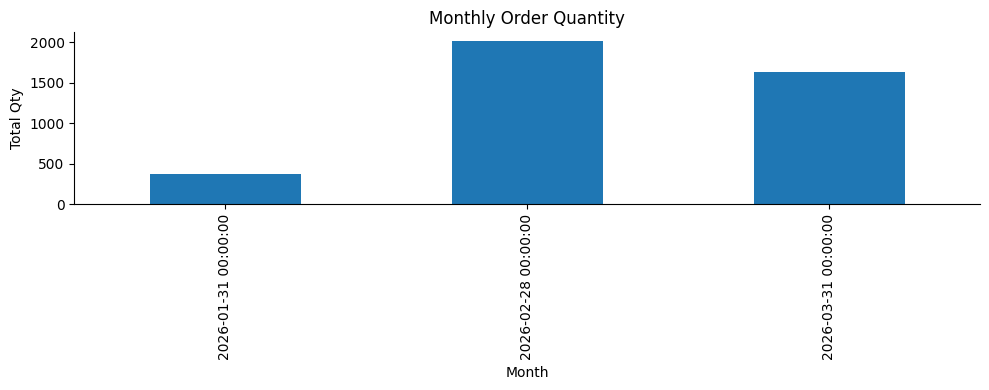

In [38]:
# Monthly order volume
monthly_orders = df.set_index('order_date').resample('ME')['order_qty'].sum()
monthly_orders.plot(kind='bar', title='Monthly Order Quantity')
plt.xlabel('Month'); plt.ylabel('Total Qty')
plt.tight_layout(); plt.show()

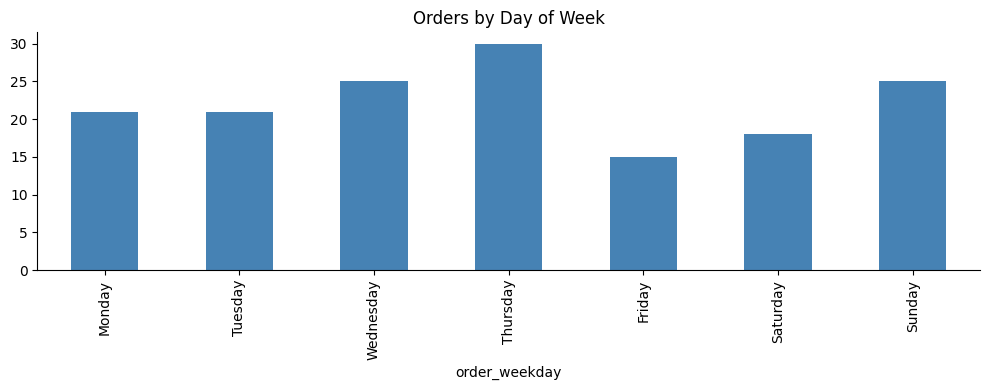

In [39]:
# Orders per weekday
weekday_counts = df['order_weekday'].value_counts()
order_days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_counts.reindex(order_days, fill_value=0).plot(kind='bar', color='steelblue')
plt.title('Orders by Day of Week')
plt.tight_layout(); plt.show()

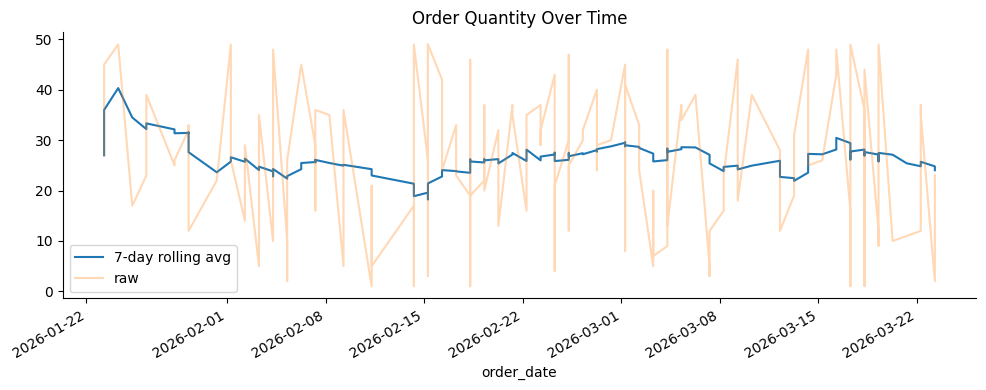

In [40]:
# Rolling 7-day average of order qty
df_ts = df.set_index('order_date').sort_index()
df_ts['order_qty'].rolling('7D').mean().plot(label='7-day rolling avg')
df_ts['order_qty'].plot(alpha=0.3, label='raw')
plt.title('Order Quantity Over Time'); plt.legend()
plt.tight_layout(); plt.show()

## 12. 🔢 NumPy Operations

In [41]:
arr = df['order_qty'].values        # pandas Series → numpy array

print("Mean:     ", np.mean(arr).round(2))
print("Median:   ", np.median(arr))
print("Std Dev:  ", np.std(arr).round(2))
print("Variance: ", np.var(arr).round(2))
print("Min/Max:  ", np.min(arr), "/", np.max(arr))
print("Quartiles:", np.percentile(arr, [25, 50, 75]))
print("Sum:      ", np.sum(arr))

Mean:      26.03
Median:    26.0
Std Dev:   13.56
Variance:  183.93
Min/Max:   1 / 49
Quartiles: [16. 26. 36.]
Sum:       4034


In [42]:
# Z-score normalization of delivery time
dt = df['delivery_time_days'].values
z_scores = (dt - np.mean(dt)) / np.std(dt)
df['delivery_z'] = z_scores

# Outliers: z > 2 or z < -2
outliers = df[np.abs(df['delivery_z']) > 2]
print(f"Outlier orders: {len(outliers)}")
outliers[['order_id', 'delivery_time_days', 'delivery_z']]

Outlier orders: 0


,order_id,delivery_time_days,delivery_z


In [43]:
# Log transform (useful for skewed data)
df['qty_log'] = np.log1p(df['order_qty'])

# Clip values to a range (remove extreme outliers)
df['qty_clipped'] = np.clip(df['order_qty'], 5, 45)

# Correlation between order qty and delivery time
qty = df['order_qty'].values
dtime = df['delivery_time_days'].values
corr_matrix = np.corrcoef(qty, dtime)
print(f"Correlation (qty vs delivery_time): {corr_matrix[0,1]:.3f}")

Correlation (qty vs delivery_time): 0.137


In [44]:
# Boolean mask with NumPy
fast_mask = df['delivery_time_days'].values <= 5
print("Fast deliveries (≤5 days):", np.sum(fast_mask))
print("Any order > 48 qty?", np.any(df['order_qty'].values > 48))
print("All qty positive?", np.all(df['order_qty'].values > 0))

Fast deliveries (≤5 days): 46
Any order > 48 qty? True
All qty positive? True


## 13. 📈 Visualizations

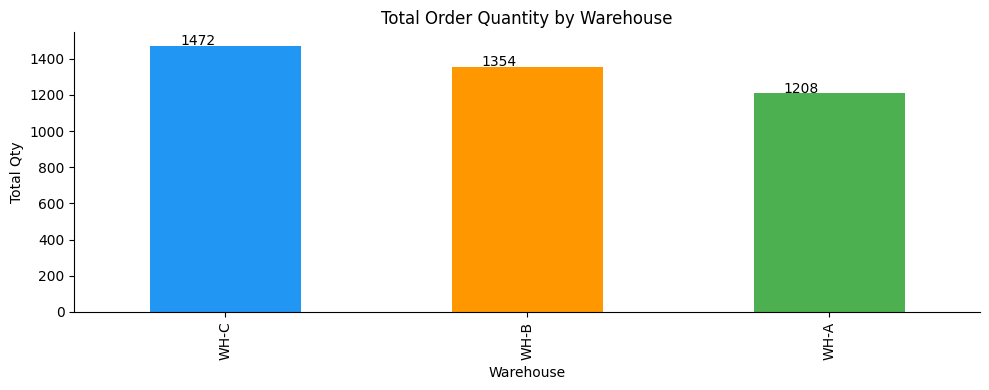

In [45]:
# Bar chart: total qty by warehouse
wh_qty = df.groupby('warehouse')['order_qty'].sum().sort_values(ascending=False)
ax = wh_qty.plot(kind='bar', color=['#2196F3','#FF9800','#4CAF50'])
ax.set_title('Total Order Quantity by Warehouse')
ax.set_xlabel('Warehouse'); ax.set_ylabel('Total Qty')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x()+0.1, p.get_height()+5), fontsize=10)
plt.tight_layout(); plt.show()

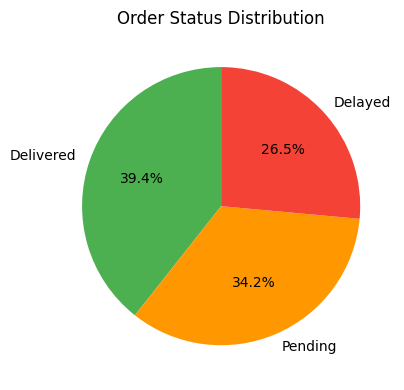

In [46]:
# Status distribution: pie chart
status_counts = df['status'].value_counts()
colors = ['#4CAF50','#FF9800','#F44336']
status_counts.plot(kind='pie', autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Order Status Distribution'); plt.ylabel('')
plt.tight_layout(); plt.show()

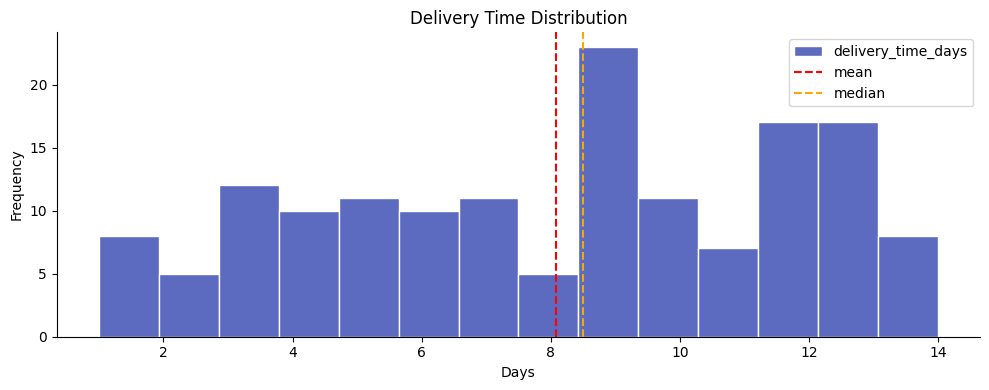

In [47]:
# Histogram: delivery time distribution
df['delivery_time_days'].plot(kind='hist', bins=14, edgecolor='white', color='#5C6BC0')
plt.axvline(df['delivery_time_days'].mean(), color='red', linestyle='--', label='mean')
plt.axvline(df['delivery_time_days'].median(), color='orange', linestyle='--', label='median')
plt.legend(); plt.title('Delivery Time Distribution')
plt.xlabel('Days'); plt.tight_layout(); plt.show()

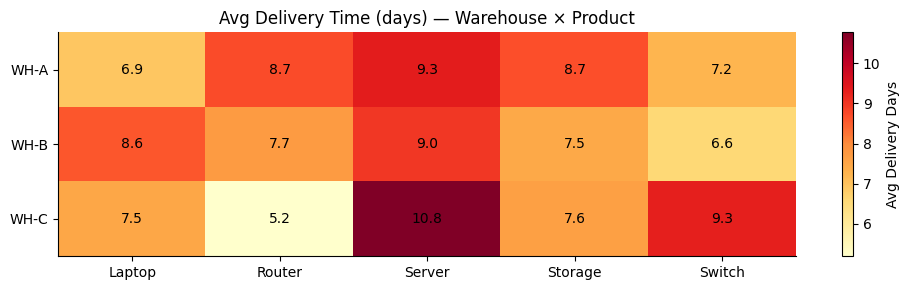

In [48]:
# Heatmap: avg delivery time per warehouse × product
pivot = df.pivot_table(values='delivery_time_days', index='warehouse',
                       columns='product', aggfunc='mean')
fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)));  ax.set_yticklabels(pivot.index)
plt.colorbar(im, ax=ax, label='Avg Delivery Days')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i,j]:.1f}", ha='center', va='center', fontsize=10)
ax.set_title('Avg Delivery Time (days) — Warehouse × Product')
plt.tight_layout(); plt.show()

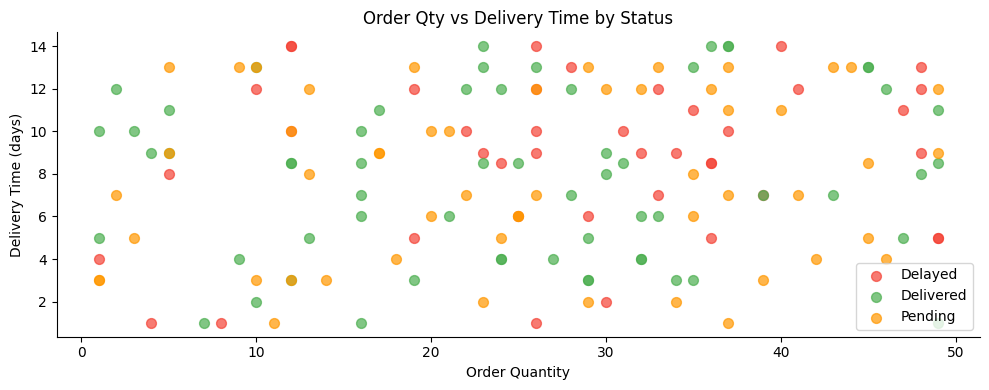

In [49]:
# Scatter: order qty vs delivery time (colored by status)
colors_map = {'Pending': '#FF9800', 'Delivered': '#4CAF50', 'Delayed': '#F44336'}
for status, group in df.groupby('status', observed=True):
    plt.scatter(group['order_qty'], group['delivery_time_days'],
                label=status, color=colors_map[status], alpha=0.7, s=50)
plt.xlabel('Order Quantity'); plt.ylabel('Delivery Time (days)')
plt.title('Order Qty vs Delivery Time by Status')
plt.legend(); plt.tight_layout(); plt.show()

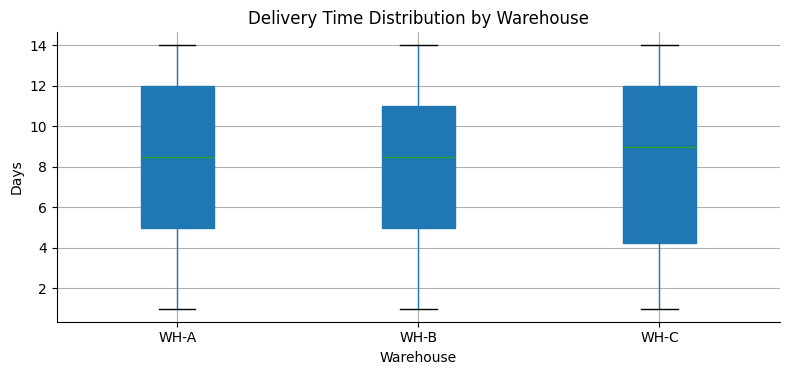

In [50]:
# Box plot: delivery time by warehouse
df.boxplot(column='delivery_time_days', by='warehouse',
           patch_artist=True, figsize=(8,4))
plt.suptitle('')
plt.title('Delivery Time Distribution by Warehouse')
plt.xlabel('Warehouse'); plt.ylabel('Days')
plt.tight_layout(); plt.show()

## 14. 🔗 Merge, Join & Concat

In [51]:
# Simulate a second orders file and concatenate
df_copy = df.sample(20, random_state=7).copy()
df_copy['order_id'] = df_copy['order_id'].str.replace('ORD-', 'ORD-Q2-')
combined = pd.concat([df, df_copy], ignore_index=True)
print("Combined shape:", combined.shape)

Combined shape: (175, 27)


In [52]:
# Simulate a warehouse capacity lookup table and merge
warehouse_info = pd.DataFrame({
    'warehouse' : ['WH-A', 'WH-B', 'WH-C'],
    'capacity'  : [500, 300, 450],
    'city'      : ['Mumbai', 'Delhi', 'Bangalore']
})
df_merged = pd.merge(df, warehouse_info, on='warehouse', how='left')
df_merged[['order_id','warehouse','city','capacity','order_qty']].head(5)

,order_id,warehouse,city,capacity,order_qty
0,ORD-1000,WH-C,Bangalore,450,42
1,ORD-1001,WH-A,Mumbai,500,30
2,ORD-1002,WH-C,Bangalore,450,19
3,ORD-1003,WH-C,Bangalore,450,17
4,ORD-1004,WH-A,Mumbai,500,19


In [53]:
# Left join vs inner join
df_inner = pd.merge(df, warehouse_info, on='warehouse', how='inner')
df_left  = pd.merge(df, warehouse_info, on='warehouse', how='left')
print("Inner:", df_inner.shape, "  Left:", df_left.shape)

Inner: (155, 29)   Left: (155, 29)


## 15. ⚡ apply(), map(), lambda

In [54]:
# map: recode one column's values
region_map = {'North': 'N', 'South': 'S', 'East': 'E', 'West': 'W', 'Unknown': 'UNK'}
df['region_code'] = df['region'].map(region_map)
df[['region', 'region_code']].drop_duplicates()

,region,region_code
0,West,W
2,South,S
3,North,N
4,East,E
49,Unknown,UNK


In [55]:
# apply on a single column with lambda
df['qty_doubled'] = df['order_qty'].apply(lambda x: x * 2)

# apply on multiple columns (axis=1 = row-wise)
df['delivery_status_flag'] = df.apply(
    lambda row: 'CRITICAL' if row['is_delayed'] and row['order_qty'] > 35 else 'OK',
    axis=1
)
df[['order_id', 'order_qty', 'is_delayed', 'delivery_status_flag']].head(8)

,order_id,order_qty,is_delayed,delivery_status_flag
0,ORD-1000,42,False,OK
1,ORD-1001,30,False,OK
2,ORD-1002,19,False,OK
3,ORD-1003,17,False,OK
4,ORD-1004,19,False,OK
5,ORD-1005,28,False,OK
6,ORD-1006,26,True,OK
7,ORD-1007,37,False,OK


In [56]:
# applymap (now called map in pandas 2.x) for element-wise on whole df
numeric_df = df[['order_qty', 'delivery_time_days']].copy()
numeric_df.map(lambda x: round(x, 0))

,order_qty,delivery_time_days
0,42,4.00
1,30,12.00
2,19,13.00
3,17,9.00
4,19,3.00
...,...,...
150,29,3.00
151,12,8.00
152,37,14.00
153,45,13.00


## 16. 🗑️ Duplicates, Index & Reset

In [57]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check for duplicate order_ids
print("Duplicate order_ids:", df['order_id'].duplicated().sum())

# Drop duplicates
df_clean = df.drop_duplicates()
df_clean = df.drop_duplicates(subset=['order_id'])

Duplicate rows: 5
Duplicate order_ids: 5


In [58]:
# Set a meaningful index
df_indexed = df.set_index('order_id')
df_indexed.loc['ORD-1010']           # access row by order ID

# Reset back to default int index
df_reset = df_indexed.reset_index()

## 17. 💾 Export Results

In [59]:
# Save cleaned dataframe to CSV
df.to_csv("supply_chain_cleaned.csv", index=False)
print("Saved: supply_chain_cleaned.csv")

Saved: supply_chain_cleaned.csv


In [60]:
# Save KPI summary to Excel
summary = df.groupby('warehouse').agg(
    total_orders  = ('order_id', 'count'),
    total_qty     = ('order_qty', 'sum'),
    avg_delivery  = ('delivery_time_days', 'mean'),
    delay_rate_pct= ('is_delayed', lambda x: round(x.mean()*100, 1))
).reset_index()

summary.to_excel("warehouse_kpi_summary.xlsx", index=False)
print("Saved: warehouse_kpi_summary.xlsx")
summary

Saved: warehouse_kpi_summary.xlsx


,warehouse,total_orders,total_qty,avg_delivery,delay_rate_pct
0,WH-A,48,1208,8.02,18.80
1,WH-B,49,1354,8.05,28.60
2,WH-C,58,1472,8.14,31.00


In [61]:
# Multiple sheets in one Excel file
with pd.ExcelWriter("supply_chain_report.xlsx", engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Raw Data', index=False)
    summary.to_excel(writer, sheet_name='Warehouse KPIs', index=False)
    df.groupby('product').agg(
        total_qty=('order_qty','sum'),
        avg_delivery=('delivery_time_days','mean')
    ).reset_index().to_excel(writer, sheet_name='Product Analysis', index=False)

print("Saved: supply_chain_report.xlsx with 3 sheets")

Saved: supply_chain_report.xlsx with 3 sheets


## 18. 🏁 Final Supply Chain KPI Dashboard

In [62]:
total_orders    = len(df)
total_qty       = df['order_qty'].sum()
delay_rate      = (df['status'] == 'Delayed').mean() * 100
avg_delivery    = df['delivery_time_days'].mean()
worst_warehouse = df.groupby('warehouse')['delivery_time_days'].mean().idxmax()
top_product     = df.groupby('product')['order_qty'].sum().idxmax()

print("=" * 45)
print("    AWS SUPPLY CHAIN — KPI SUMMARY")
print("=" * 45)
print(f"  Total Orders        : {total_orders}")
print(f"  Total Units Ordered : {total_qty:,}")
print(f"  Delay Rate          : {delay_rate:.1f}%")
print(f"  Avg Delivery Time   : {avg_delivery:.1f} days")
print(f"  Slowest Warehouse   : {worst_warehouse}")
print(f"  Top Product (qty)   : {top_product}")
print("=" * 45)

    AWS SUPPLY CHAIN — KPI SUMMARY
  Total Orders        : 155
  Total Units Ordered : 4,034
  Delay Rate          : 26.5%
  Avg Delivery Time   : 8.1 days
  Slowest Warehouse   : WH-C
  Top Product (qty)   : Laptop
